# Predictive Information Across Halo Representations
## Engineered Summaries, Unordered Halo Sets, Static Graphs, and a Temporal Graph Reference for $\Omega_m$ Regression

CAMELS-SIMBA · U1000 · Top500/1000/1500/2000 · three matched seeds

**Primary question.** Within matched final-snapshot halo populations, how much predictive value for $\Omega_m$ is captured by engineered catalogue summaries, raw permutation-invariant halo sets, and explicit graph structure, and how does the existing five-snapshot EvolveGCN-H model compare as a contextual temporal reference?

This notebook is an artifact-only analysis. It performs no training and no checkpoint inference. Every numerical result is derived from validated saved configurations, manifests, metrics, and prediction CSVs.

# 1 — Research Question and Motivation

The analysis follows a representation ladder rather than a leaderboard. It first establishes whether learnable signal exists, then asks what nonlinear model class adds under a fixed summary representation, whether a neural model can learn directly from an unordered halo population, whether graph message passing improves that raw-halo model, and finally how the five-snapshot temporal graph reference compares. Top-N scaling and target-range coverage are treated as cross-cutting diagnostics.

# 2 — Experimental Design and Representation Ladder

The **final-snapshot information-matched core** uses $a=1.00000$: Ridge, Random Forest, Gradient Boosting, Summary MLP, DeepSets, and Static GCN. Mean is a trivial target-only reference. EvolveGCN-H receives five snapshots, $[0.2, 0.25, 0.51209, 0.75065, 1.0]$, and is therefore a **contextual temporal reference**, not a strict information-matched comparison and not a clean estimate of the value of temporal information.

All comparisons use seeds 42, 123, and 2025 with ordered 700/99/201 train/validation/test partitions. Top750 is deliberately excluded: Notebook 12 provides the denser GNN-only scaling study.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib, json, math, re, subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

def find_repo_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / '.git').exists() and (candidate / 'experiments').is_dir():
            return candidate
    raise RuntimeError('Repository root could not be resolved.')

REPO = find_repo_root()
OUTPUT_DIR = REPO / 'notebooks/visualization/outputs/13_u1000_representation_model_comparison'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TOP_NS = [500, 1000, 1500, 2000]
SEEDS = [42, 123, 2025]
PARTITIONS = {'train': 700, 'val': 99, 'test': 201}
RTOL, ATOL = 1e-9, 1e-12
CREATED_AT = datetime.now(timezone.utc).isoformat()
SUMMARY_FEATURES = ['halo_count','log10_Mvir_mean','log10_Mvir_std','log10_Mvir_min','log10_Mvir_max','log10_Mvir_median','X_mean','Y_mean','Z_mean','X_std','Y_std','Z_std','VX_mean','VY_mean','VZ_mean','VX_std','VY_std','VZ_std','speed_mean','speed_std']
RAW_FEATURES = ['log10_Mvir','X','Y','Z','VX','VY','VZ']
SNAPSHOTS = [0.2, 0.25, 0.51209, 0.75065, 1.0]
MODELS = ['Mean','Ridge','Random Forest','Gradient Boosting','Summary MLP','DeepSets','Static GCN','EvolveGCN-H']
FINAL_MODELS = ['Ridge','Random Forest','Gradient Boosting','Summary MLP','DeepSets','Static GCN']
MODEL_SPECS = {
    'Mean': ('mean_baseline_u1000_train700_seed{seed}_targetmean', 1),
    'Ridge': ('ridge_u1000_top{top}_summary20_final_train700_seed{seed}_trainzscore_alpha1', 4),
    'Random Forest': ('random_forest_u1000_top{top}_summary20_final_train700_seed{seed}_none_t300_leaf2', 4),
    'Gradient Boosting': ('gradient_boosting_u1000_top{top}_summary20_final_train700_seed{seed}_none_t300_lr0p03_d3', 4),
    'Summary MLP': ('summary_mlp_u1000_top{top}_summary20_final_train700_seed{seed}_trainzscore_h64x64_drop0p2', 4),
    'DeepSets': ('deepsets_u1000_top{top}_raw7_final_train700_seed{seed}_none_h32_phi3_mean_statichead', 4),
    'Static GCN': ('static_gcn_u1000_top{top}_sparse_train700_seed{seed}_none_h32_l3_mean_mlp_final', 4),
    'EvolveGCN-H': ('evolvegcn_h_u1000_top{top}_sparse_train700_seed{seed}_none_h32_l2_mean_temporal_mean_linear', 4),
}
STYLES = {
    'Mean': dict(color='#7f7f7f', marker='x', linestyle=':'),
    'Ridge': dict(color='#4C78A8', marker='o', linestyle='-'),
    'Random Forest': dict(color='#59A14F', marker='s', linestyle='-'),
    'Gradient Boosting': dict(color='#E15759', marker='D', linestyle='-'),
    'Summary MLP': dict(color='#B279A2', marker='^', linestyle='-'),
    'DeepSets': dict(color='#F28E2B', marker='v', linestyle='-'),
    'Static GCN': dict(color='#76B7B2', marker='P', linestyle='-'),
    'EvolveGCN-H': dict(color='#EDC948', marker='X', linestyle='--'),
}
plt.rcParams.update({'figure.dpi': 115, 'savefig.dpi': 240, 'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 9.5})

def savefig(fig, name):
    path = OUTPUT_DIR / name
    fig.savefig(path, dpi=240, bbox_inches='tight', transparent=True)
    plt.show()
    return path

print(f'Repository: {REPO}')
print(f'Analysis timestamp (UTC): {CREATED_AT}')

Repository: /home/ml/thesis-camels
Analysis timestamp (UTC): 2026-08-24T20:51:59.849732+00:00


## Table 1 — Information budget

The table makes the information-budget distinction explicit before any performance result is shown.

In [2]:
table01 = pd.DataFrame([
 ['Mean','Training-target mean','Target only','—','No','No','No','No','Constant','0','Trivial reference'],
 ['Ridge','u1000_final_summary20_v1','Catalogue','a=1.00000','Yes (20)','No','No','No','—','21','Linear summary baseline'],
 ['Random Forest','u1000_final_summary20_v1','Catalogue','a=1.00000','Yes (20)','No','No','No','Tree aggregation','Not meaningful','Nonlinear summary baseline'],
 ['Gradient Boosting','u1000_final_summary20_v1','Catalogue','a=1.00000','Yes (20)','No','No','No','Tree aggregation','Not meaningful','Strong nonlinear summary baseline'],
 ['Summary MLP','u1000_final_summary20_v1','Catalogue','a=1.00000','Yes (20)','No','No','No','—','5,569','Neural summary baseline'],
 ['DeepSets','Raw seven-feature halo set','Individual halos','a=1.00000','No','Yes','No','No','Masked mean','4,161','Raw unordered-set model'],
 ['Static GCN','Raw seven-feature periodic kNN graph','Individual halos + edges','a=1.00000','No','Yes','Yes: k=8','No','Mean graph','5,281','Raw static graph model'],
 ['EvolveGCN-H','Five raw-halo graph snapshots','Individual halos + edges','0.2, 0.25, 0.51209, 0.75065, 1.0','No','Yes','Yes: k=8','Yes','Mean graph; mean temporal','3,408,097','Contextual temporal graph reference'],
], columns=['Model','Representation','Input level','Snapshots','Engineered summaries?','Raw halos?','Graph edges?','Temporal?','Pooling','Approx. trainable parameters','Primary role in study'])
table01.to_csv(OUTPUT_DIR/'table01_information_budget.csv', index=False)
display(table01)

,Model,Representation,Input level,Snapshots,Engineered summaries?,Raw halos?,Graph edges?,Temporal?,Pooling,Approx. trainable parameters,Primary role in study
0,Mean,Training-target mean,Target only,—,No,No,No,No,Constant,0,Trivial reference
1,Ridge,u1000_final_summary20_v1,Catalogue,a=1.00000,Yes (20),No,No,No,—,21,Linear summary baseline
2,Random Forest,u1000_final_summary20_v1,Catalogue,a=1.00000,Yes (20),No,No,No,Tree aggregation,Not meaningful,Nonlinear summary baseline
3,Gradient Boosting,u1000_final_summary20_v1,Catalogue,a=1.00000,Yes (20),No,No,No,Tree aggregation,Not meaningful,Strong nonlinear summary baseline
4,Summary MLP,u1000_final_summary20_v1,Catalogue,a=1.00000,Yes (20),No,No,No,—,"5,569",Neural summary baseline
5,DeepSets,Raw seven-feature halo set,Individual halos,a=1.00000,No,Yes,No,No,Masked mean,"4,161",Raw unordered-set model
6,Static GCN,Raw seven-feature periodic kNN graph,Individual halos + edges,a=1.00000,No,Yes,Yes: k=8,No,Mean graph,"5,281",Raw static graph model
7,EvolveGCN-H,Five raw-halo graph snapshots,Individual halos + edges,"0.2, 0.25, 0.51209, 0.75065, 1.0",No,Yes,Yes: k=8,Yes,Mean graph; mean temporal,"3,408,097",Contextual temporal graph reference


# 3 — Integrity and Fairness Gate

**Mandatory gate.** The next cell independently resolves the exact 87-run experiment set; validates required artifacts, model/config identity, actual dataset and manifest SHA-256 values, split counts and ordered IDs, target values, snapshot and feature protocols, and prediction-derived metrics; and then verifies matched ordered splits and truths. A failed assertion stops execution before any scientific result.

In [3]:
def sha256(path):
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for block in iter(lambda: handle.read(8 * 1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

def metrics_from_predictions(frame):
    truth = frame.true_omega_m.to_numpy(float)
    pred = frame.pred_omega_m.to_numpy(float)
    residual = pred - truth
    mse = float(np.mean(residual**2))
    denom = float(np.sum((truth-truth.mean())**2))
    return {'mse':mse, 'rmse':math.sqrt(mse), 'mae':float(np.mean(np.abs(residual))), 'r2':1-float(np.sum(residual**2))/denom, 'num_samples':len(frame)}

expected_dataset = {n:f'data/processed/temporal_1000u_none_top{n}_periodic_knn_sparse/camels_1000u_temporal_logmass_none_top{n}_periodic_knn_sparse.pt' for n in TOP_NS}
metadata_cache, dataset_hashes, manifest_cache, manifest_hashes = {}, {}, {}, {}
for top in TOP_NS:
    dpath = REPO/expected_dataset[top]
    mpath = dpath.with_suffix('.metadata.json')
    assert dpath.is_file() and dpath.stat().st_size > 0
    assert mpath.is_file() and mpath.stat().st_size > 0
    dataset_hashes[top] = sha256(dpath)
    metadata_cache[top] = json.loads(mpath.read_text())
    meta = metadata_cache[top]
    assert meta['checksum'] == dataset_hashes[top]
    assert meta['num_nodes'] == top and meta['num_universes_successful'] == 1000
    assert meta['feature_names'] == RAW_FEATURES and meta['normalization'] == 'none'
    assert meta['graph_mode'] == 'knn' and meta['k'] == 8 and meta['box_size'] == 25.0
    assert meta['num_snapshots'] == 5 and np.allclose(meta['snapshot_ids'], SNAPSHOTS, rtol=0, atol=1e-12)
    for seed in SEEDS:
        rel = f'configs/splits/u1000_top{top}_none_k8_sparse/seed{seed}_train700.json'
        path = REPO/rel
        assert path.is_file() and path.stat().st_size > 0
        manifest_cache[(top,seed)] = json.loads(path.read_text())
        manifest_hashes[(top,seed)] = sha256(path)
        man = manifest_cache[(top,seed)]
        assert man['dataset_binding']['dataset_path'] == expected_dataset[top]
        assert man['dataset_identity'] == dataset_hashes[top]
        assert man['counts'] == {'population':1000,'test':201,'train':700,'unused':0,'val':99}
        assert man['graph_protocol_summary']['top_n'] == top and man['graph_protocol_summary']['k'] == 8
        assert man['feature_protocol_summary']['feature_names'] == RAW_FEATURES

run_rows, metric_rows, prediction_frames = [], [], []
truth_reference, id_reference = {}, {}
metric_comparisons = 0
prediction_files_checked = 0

for model in MODELS:
    template, top_count = MODEL_SPECS[model]
    tops = [None] if model == 'Mean' else TOP_NS
    for top in tops:
        for seed in SEEDS:
            name = template.format(top=top, seed=seed)
            run = REPO/'experiments'/name
            assert run.is_dir(), f'Missing run: {name}'
            base_required = ['config.json','metrics.json','predictions/train_predictions.csv','predictions/val_predictions.csv','predictions/test_predictions.csv']
            if model in ['Ridge','Random Forest','Gradient Boosting']:
                base_required += ['model.joblib']
            if model in ['Summary MLP','DeepSets','Static GCN','EvolveGCN-H']:
                base_required += ['train_log.csv','checkpoints/best_model.pt']
            for rel in base_required:
                artifact = run/rel
                assert artifact.is_file() and artifact.stat().st_size > 0, f'Missing/empty artifact: {artifact}'
            cfg = json.loads((run/'config.json').read_text())
            saved = json.loads((run/'metrics.json').read_text())
            assert cfg['experiment_name'] == name
            actual_top = 1000 if model == 'Mean' else top
            dataset_rel = expected_dataset[actual_top]
            split_rel = f'configs/splits/u1000_top{actual_top}_none_k8_sparse/seed{seed}_train700.json'
            man = manifest_cache[(actual_top,seed)]
            cfg_dataset = cfg['dataset_path']
            cfg_split = cfg.get('split_manifest_path', cfg.get('split_source'))
            cfg_dsha = cfg.get('dataset_sha256', cfg.get('dataset_identity', cfg.get('dataset_provenance',{}).get('dataset_sha256')))
            assert cfg_dataset == dataset_rel and cfg_split == split_rel
            assert cfg_dsha == dataset_hashes[actual_top]
            assert cfg['split_manifest_sha256'] == manifest_hashes[(actual_top,seed)]
            assert cfg['seed'] == seed

            if model in ['Mean','Ridge','Random Forest','Gradient Boosting','Summary MLP']:
                assert cfg['representation'] == 'engineered_summary'
                assert cfg['summary_definition_version'] == 'u1000_final_summary20_v1'
                assert cfg['feature_names'] == SUMMARY_FEATURES and cfg['feature_count'] == 20
                assert cfg['snapshot_protocol'] == 'final' and cfg['final_scale_factor'] == 1.0
                expected_family = {'Mean':'mean','Ridge':'ridge','Random Forest':'random_forest','Gradient Boosting':'gradient_boosting','Summary MLP':'summary_mlp'}[model]
                assert cfg['model_family'] == expected_family
            elif model == 'DeepSets':
                assert cfg['model_family'] == 'deepsets' and cfg['representation'] == 'raw_halo_set'
                assert cfg['feature_names'] == RAW_FEATURES and cfg['feature_count'] == 7
                assert cfg['uses_graph_edges'] is False and cfg['pooling'] == 'masked_mean'
                assert cfg['snapshot_protocol'] == 'final' and cfg['final_scale_factor'] == 1.0
            elif model == 'Static GCN':
                assert cfg['model'] == 'StaticGCNRegressor' and cfg['dataset_format'] == 'temporal_final_snapshot'
                assert cfg['num_nodes'] == top and cfg['node_features'] == 7
                assert cfg['conv_type'] == 'gcn' and cfg['graph_pooling'] == 'mean'
            else:
                assert cfg['model'] == 'EvolveGCNHRegressor' and cfg['num_snapshots'] == 5
                assert cfg['num_nodes'] == top and cfg['node_features'] == 7
                assert cfg['graph_pooling'] == 'mean' and cfg['temporal_pooling'] == 'mean'

            best_epoch = saved.get('best_epoch', np.nan)
            for part, count in PARTITIONS.items():
                pred = pd.read_csv(run/'predictions'/f'{part}_predictions.csv')
                prediction_files_checked += 1
                assert list(pred.columns) == ['universe_id','true_omega_m','pred_omega_m','absolute_error','squared_error']
                assert len(pred) == count and pred.universe_id.is_unique
                assert pred.universe_id.tolist() == man[f'{part}_ids']
                assert np.isfinite(pred[['true_omega_m','pred_omega_m','absolute_error','squared_error']].to_numpy()).all()
                resid = pred.pred_omega_m.to_numpy(float)-pred.true_omega_m.to_numpy(float)
                assert np.allclose(pred.absolute_error, np.abs(resid), rtol=RTOL, atol=ATOL)
                assert np.allclose(pred.squared_error, resid**2, rtol=RTOL, atol=ATOL)
                calc = metrics_from_predictions(pred)
                saved_key = 'validation' if model in ['Summary MLP','DeepSets'] and part == 'val' else part
                for key in ['mse','rmse','mae','r2']:
                    assert np.isclose(calc[key], saved[saved_key][key], rtol=RTOL, atol=ATOL), f'{name} {part} {key}'
                    metric_comparisons += 1
                assert saved[saved_key]['num_samples'] == count
                ref_key = (actual_top,seed,part)
                ids, truths = pred.universe_id.tolist(), pred.true_omega_m.to_numpy(float)
                if ref_key in id_reference:
                    assert ids == id_reference[ref_key] and np.array_equal(truths, truth_reference[ref_key])
                else:
                    id_reference[ref_key], truth_reference[ref_key] = ids, truths
                prediction_frames.append(pred.assign(Model=model, **{'Top-N':top if top is not None else 1000,'Seed':seed,'Partition':part}))
                metric_rows.append({'Model':model,'Top-N':top if top is not None else np.nan,'Seed':seed,'Partition':part,**calc,'Best epoch':best_epoch})
            run_rows.append({'Model':model,'Top-N':top if top is not None else np.nan,'Seed':seed,'Experiment':name,'Dataset path':dataset_rel,'Dataset SHA256':dataset_hashes[actual_top],'Split manifest':split_rel,'Split manifest SHA256':manifest_hashes[(actual_top,seed)],'Best epoch':best_epoch})

# Mean is Top-N invariant and must match every seed-specific partition.
predictions = pd.concat(prediction_frames, ignore_index=True)
for top in TOP_NS:
    for seed in SEEDS:
        for part in PARTITIONS:
            mean_frame = predictions[(predictions.Model=='Mean')&(predictions.Seed==seed)&(predictions.Partition==part)]
            assert mean_frame.universe_id.tolist() == id_reference[(top,seed,part)]
            assert np.array_equal(mean_frame.true_omega_m.to_numpy(float), truth_reference[(top,seed,part)])

runs = pd.DataFrame(run_rows)
metrics = pd.DataFrame(metric_rows)
assert len(runs) == 87 and runs.Experiment.nunique() == 87
assert len(predictions) == 87*1000
assert runs.groupby('Model').size().to_dict() == {'Mean':3,'Ridge':12,'Random Forest':12,'Gradient Boosting':12,'Summary MLP':12,'DeepSets':12,'Static GCN':12,'EvolveGCN-H':12}
assert not runs.duplicated(['Model','Top-N','Seed']).any()
table10 = runs.copy()
table10.to_csv(OUTPUT_DIR/'table10_run_provenance.csv', index=False)
print(f'INTEGRITY GATE: PASS — {len(runs)}/87 runs; {prediction_files_checked} prediction files; {metric_comparisons} metric comparisons; 0 failures.')
print('FAIRNESS GATE: PASS — ordered train/validation/test IDs and true Omega_m match for every Top-N × seed; Mean matches each seed-specific training partition.')

INTEGRITY GATE: PASS — 87/87 runs; 261 prediction files; 1044 metric comparisons; 0 failures.
FAIRNESS GATE: PASS — ordered train/validation/test IDs and true Omega_m match for every Top-N × seed; Mean matches each seed-specific training partition.


The gates establish experiment completeness and data alignment, not merely filename consistency. Scientific results below are displayed only after all assertions pass.

# 4 — Is There Learnable $\Omega_m$ Signal?

Question 1 compares the training-target Mean reference with Ridge. Question 2 then compares Ridge with Random Forest and Gradient Boosting to test whether nonlinear model classes exploit the same 20 engineered summaries more effectively.

In [4]:
test_seed = metrics[metrics.Partition=='test'].copy()
nonmean_summary = (test_seed[test_seed.Model!='Mean'].groupby(['Model','Top-N'],sort=False)[['mae','rmse','r2']].agg(['mean','std']).reset_index())
nonmean_summary.columns = ['Model','Top-N','MAE mean','MAE SD','RMSE mean','RMSE SD','R2 mean','R2 SD']
mean_summary = test_seed[test_seed.Model=='Mean'][['mae','rmse','r2']].agg(['mean','std'])
mean_row = pd.DataFrame([{'Model':'Mean','Top-N':np.nan,'MAE mean':mean_summary.loc['mean','mae'],'MAE SD':mean_summary.loc['std','mae'],'RMSE mean':mean_summary.loc['mean','rmse'],'RMSE SD':mean_summary.loc['std','rmse'],'R2 mean':mean_summary.loc['mean','r2'],'R2 SD':mean_summary.loc['std','r2']}])
table02 = pd.concat([mean_row,nonmean_summary],ignore_index=True)
table02['Model'] = pd.Categorical(table02.Model, MODELS, ordered=True)
table02 = table02.sort_values(['Model','Top-N']).reset_index(drop=True)
table02['Model'] = table02.Model.astype(str)
table02.to_csv(OUTPUT_DIR/'table02_main_performance.csv', index=False)
ridge_best = table02[table02.Model=='Ridge'].sort_values('MAE mean').iloc[0]
mean_mae = mean_row.iloc[0]['MAE mean']
display(Markdown(f"Ridge reaches **{ridge_best['MAE mean']:.5f} ± {ridge_best['MAE SD']:.5f} MAE** at Top{int(ridge_best['Top-N'])}, versus **{mean_mae:.5f}** for Mean. The final-snapshot catalogue therefore contains strong predictive information accessible through low-dimensional global statistics."))
display(table02.style.format({'Top-N':lambda x:'Invariant' if pd.isna(x) else f'{int(x)}','MAE mean':'{:.6f}','MAE SD':'{:.6f}','RMSE mean':'{:.6f}','RMSE SD':'{:.6f}','R2 mean':'{:.4f}','R2 SD':'{:.4f}'}))

Ridge reaches **0.02247 ± 0.00037 MAE** at Top1000, versus **0.10363** for Mean. The final-snapshot catalogue therefore contains strong predictive information accessible through low-dimensional global statistics.

,Model,Top-N,MAE mean,MAE SD,RMSE mean,RMSE SD,R2 mean,R2 SD
0,Mean,Invariant,0.103631,0.003979,0.118874,0.004041,-0.0059,0.0046
1,Ridge,500,0.024527,0.000477,0.030876,0.000652,0.9321,0.0016
2,Ridge,1000,0.022471,0.000365,0.028378,0.000477,0.9426,0.0031
3,Ridge,1500,0.023970,0.000480,0.030243,0.000344,0.9348,0.0031
4,Ridge,2000,0.024858,0.000591,0.030823,0.000016,0.9322,0.0045
5,Random Forest,500,0.011674,0.000252,0.015580,0.000556,0.9827,0.0004
6,Random Forest,1000,0.010093,0.000463,0.013484,0.000536,0.9870,0.0011
7,Random Forest,1500,0.009376,0.000536,0.012434,0.000672,0.9890,0.0012
8,Random Forest,2000,0.009262,0.000436,0.012346,0.000598,0.9891,0.0013
9,Gradient Boosting,500,0.011500,0.000231,0.015056,0.000406,0.9838,0.0009


# 5 — Main Cross-Model Performance

The overview retains the representation-ladder order. Panel A is the final-snapshot information-matched study; Panel B separates the static graph from the five-snapshot EvolveGCN-H contextual reference.

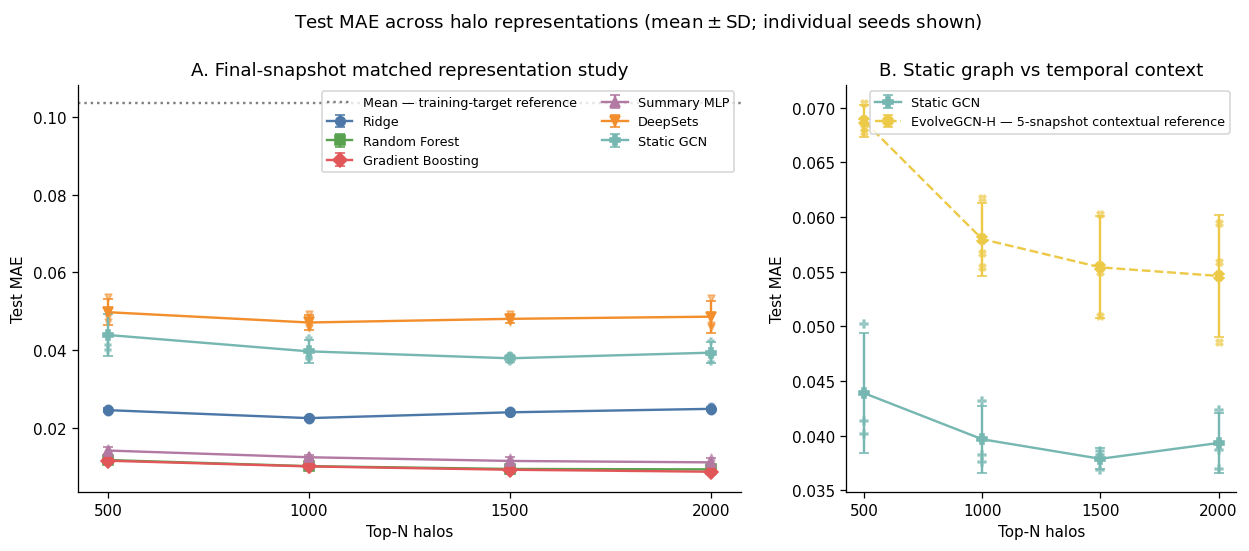

In [5]:
fig, axes = plt.subplots(1,2,figsize=(13,4.6),gridspec_kw={'width_ratios':[1.7,1]})
ax=axes[0]
for model in FINAL_MODELS:
    g=test_seed[test_seed.Model==model].groupby('Top-N').mae.agg(['mean','std'])
    st=STYLES[model]
    ax.errorbar(g.index,g['mean'],yerr=g['std'],label=model,capsize=3,**st)
    raw=test_seed[test_seed.Model==model]
    ax.scatter(raw['Top-N'],raw.mae,s=18,color=st['color'],marker=st['marker'],alpha=.55)
ax.axhline(mean_mae,color=STYLES['Mean']['color'],ls=':',label='Mean — training-target reference')
ax.set(title='A. Final-snapshot matched representation study',xlabel='Top-N halos',ylabel='Test MAE',xticks=TOP_NS)
ax.legend(ncol=2,fontsize=8)
ax=axes[1]
for model in ['Static GCN','EvolveGCN-H']:
    g=test_seed[test_seed.Model==model].groupby('Top-N').mae.agg(['mean','std']); st=STYLES[model]
    label=model if model=='Static GCN' else 'EvolveGCN-H — 5-snapshot contextual reference'
    ax.errorbar(g.index,g['mean'],yerr=g['std'],label=label,capsize=3,**st)
    raw=test_seed[test_seed.Model==model]; ax.scatter(raw['Top-N'],raw.mae,s=20,color=st['color'],marker=st['marker'],alpha=.6)
ax.set(title='B. Static graph vs temporal context',xlabel='Top-N halos',ylabel='Test MAE',xticks=TOP_NS)
ax.legend(fontsize=8)
fig.suptitle(r'Test MAE across halo representations ($\mathrm{mean}\pm\mathrm{SD}$; individual seeds shown)',y=1.02)
fig01=savefig(fig,'fig01_test_mae_vs_topn.png')

**What this figure shows.** The engineered-summary models occupy a distinctly lower-error regime than the tested raw-halo neural models. Static GCN improves on DeepSets throughout the grid. EvolveGCN-H is shown separately because its five snapshots give it a different information budget.

# 6 — Engineered Summaries: Linear vs Nonlinear vs Neural Regression

Because Ridge, Random Forest, Gradient Boosting, and Summary MLP consume the same 20 features and matched splits, this comparison isolates model-class effects more cleanly than cross-representation comparisons.

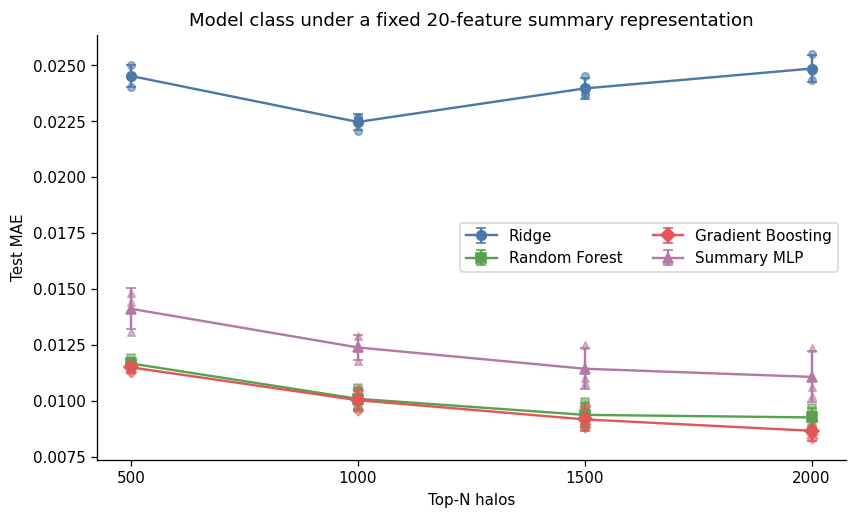

Top500: RF is 52.4% and GB is 53.1% lower-MAE than Ridge.
Top1000: RF is 55.1% and GB is 55.4% lower-MAE than Ridge.
Top1500: RF is 60.9% and GB is 61.7% lower-MAE than Ridge.
Top2000: RF is 62.7% and GB is 65.1% lower-MAE than Ridge.


In [6]:
fig,ax=plt.subplots(figsize=(8.4,4.8))
for model in ['Ridge','Random Forest','Gradient Boosting','Summary MLP']:
    g=test_seed[test_seed.Model==model].groupby('Top-N').mae.agg(['mean','std']); st=STYLES[model]
    ax.errorbar(g.index,g['mean'],yerr=g['std'],label=model,capsize=3,**st)
    raw=test_seed[test_seed.Model==model]; ax.scatter(raw['Top-N'],raw.mae,s=22,color=st['color'],marker=st['marker'],alpha=.55)
ax.set(title='Model class under a fixed 20-feature summary representation',xlabel='Top-N halos',ylabel='Test MAE',xticks=TOP_NS)
ax.legend(ncol=2)
fig02=savefig(fig,'fig02_engineered_summary_models.png')

for top in TOP_NS:
    ridge=table02[(table02.Model=='Ridge')&(table02['Top-N']==top)]['MAE mean'].iloc[0]
    rf=table02[(table02.Model=='Random Forest')&(table02['Top-N']==top)]['MAE mean'].iloc[0]
    gb=table02[(table02.Model=='Gradient Boosting')&(table02['Top-N']==top)]['MAE mean'].iloc[0]
    print(f'Top{top}: RF is {(ridge-rf)/ridge*100:.1f}% and GB is {(ridge-gb)/ridge*100:.1f}% lower-MAE than Ridge.')

**Scientific interpretation.** Nonlinear trees substantially outperform Ridge at every Top-N, supporting a strongly nonlinear relationship between these engineered summaries and $\Omega_m$ under the tested representations. The Summary MLP is also strong, showing that neural regression itself is not inherently unable to learn the target; nevertheless, both tree ensembles outperform it in every tested cell. The summaries are highly informative, but they are not claimed to be sufficient statistics.

# 7 — Raw Halo Sets: DeepSets

DeepSets receives the raw final-snapshot seven-feature halo population with masked mean pooling and no graph edges. Under the tested architecture, direct permutation-invariant learning from the raw halo set does not recover the performance achieved by the engineered summary representation. This is an architecture-and-representation result—not evidence that the raw halos intrinsically contain less information.

# 8 — Does Graph Message Passing Help?

DeepSets and Static GCN use the same final-snapshot halo populations and seven raw features. Their matched-seed comparison is the closest available test of whether the graph-based representation helps.

,Top-N,Seed,DeepSets MAE,Static GCN MAE,DeepSets - Static MAE,Relative difference %,Winner
0,500.000000,42,0.053609,0.050230,0.003379,6.30,Static GCN
1,500.000000,123,0.047273,0.040137,0.007136,15.09,Static GCN
2,500.000000,2025,0.048411,0.041314,0.007097,14.66,Static GCN
3,1000.000000,42,0.049396,0.043182,0.006214,12.58,Static GCN
4,1000.000000,123,0.045637,0.037621,0.008016,17.56,Static GCN
5,1000.000000,2025,0.046301,0.038219,0.008082,17.46,Static GCN
6,1500.000000,42,0.049171,0.038196,0.010975,22.32,Static GCN
7,1500.000000,123,0.047666,0.036829,0.010837,22.73,Static GCN
8,1500.000000,2025,0.047315,0.038635,0.008680,18.35,Static GCN
9,2000.000000,42,0.053398,0.042387,0.011011,20.62,Static GCN


Static wins: 12/12 | DeepSets wins: 0/12
Mean DeepSets−Static MAE by Top-N:


,Mean delta
Top-N,
500.0,0.005871
1000.0,0.007437
1500.0,0.010164
2000.0,0.009279


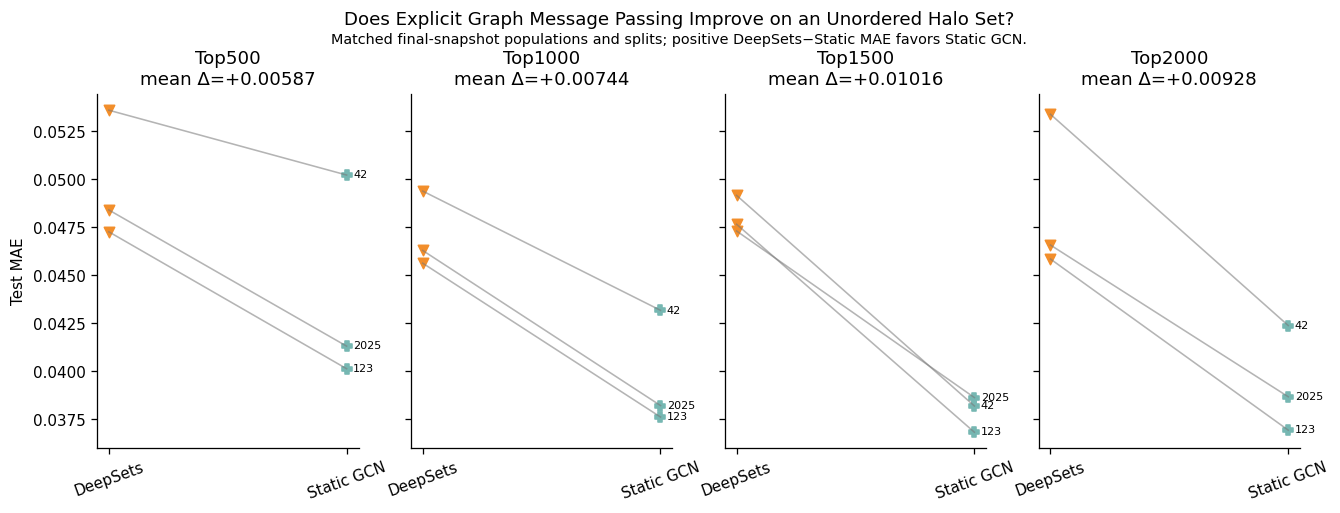

In [7]:
ds=test_seed[test_seed.Model=='DeepSets'][['Top-N','Seed','mae']].rename(columns={'mae':'DeepSets MAE'})
sg=test_seed[test_seed.Model=='Static GCN'][['Top-N','Seed','mae']].rename(columns={'mae':'Static GCN MAE'})
table05=ds.merge(sg,on=['Top-N','Seed'])
table05['DeepSets - Static MAE']=table05['DeepSets MAE']-table05['Static GCN MAE']
table05['Relative difference %']=100*table05['DeepSets - Static MAE']/table05['DeepSets MAE']
table05['Winner']=np.where(table05['DeepSets - Static MAE']>0,'Static GCN','DeepSets')
table05=table05.sort_values(['Top-N','Seed']).reset_index(drop=True)
table05.to_csv(OUTPUT_DIR/'table05_deepsets_vs_static.csv',index=False)
display(table05.style.format({c:'{:.6f}' for c in ['DeepSets MAE','Static GCN MAE','DeepSets - Static MAE']}).format({'Relative difference %':'{:.2f}'}))
print(f"Static wins: {(table05.Winner=='Static GCN').sum()}/12 | DeepSets wins: {(table05.Winner=='DeepSets').sum()}/12")
print('Mean DeepSets−Static MAE by Top-N:')
display(table05.groupby('Top-N')['DeepSets - Static MAE'].mean().to_frame('Mean delta'))

fig,axes=plt.subplots(1,4,figsize=(13.5,4),sharey=True)
for ax,top in zip(axes,TOP_NS):
    sub=table05[table05['Top-N']==top]
    for _,r in sub.iterrows():
        ax.plot([0,1],[r['DeepSets MAE'],r['Static GCN MAE']],color='#777777',alpha=.55,lw=1)
        ax.scatter(0,r['DeepSets MAE'],color=STYLES['DeepSets']['color'],marker=STYLES['DeepSets']['marker'],s=42)
        ax.scatter(1,r['Static GCN MAE'],color=STYLES['Static GCN']['color'],marker=STYLES['Static GCN']['marker'],s=42)
        ax.annotate(str(int(r.Seed)),(1,r['Static GCN MAE']),xytext=(4,0),textcoords='offset points',fontsize=7,va='center')
    delta=sub['DeepSets - Static MAE'].mean()
    ax.set(title=f'Top{top}\nmean Δ={delta:+.5f}',xticks=[0,1],xticklabels=['DeepSets','Static GCN'])
    ax.tick_params(axis='x',rotation=20)
axes[0].set_ylabel('Test MAE')
fig.suptitle('Does Explicit Graph Message Passing Improve on an Unordered Halo Set?',y=1.06)
fig.text(.5,.99,'Matched final-snapshot populations and splits; positive DeepSets−Static MAE favors Static GCN.',ha='center',fontsize=9)
fig03=savefig(fig,'fig03_deepsets_vs_static_paired.png')

**Scientific interpretation.** Within the closely matched final-snapshot raw-halo comparison, the tested Static GCN consistently outperforms the tested DeepSets model. The tested graph-based model therefore extracts predictive information more effectively than the tested unordered-set model, but this comparison does not isolate graph edges alone because parameter count and precise node transformations also differ. Twelve matched wins are descriptive evidence; with only three seeds, no formal significance claim is made.

# 9 — Temporal Graph Context: Static vs EvolveGCN-H

The tested five-snapshot EvolveGCN-H contextual temporal reference does not outperform Static GCN in the tested cells. This comparison is not a causal estimate of the value of temporal information: Static GCN receives one final snapshot, EvolveGCN-H receives five snapshots, and their architectures, parameterizations, and optimization differ.

In [8]:
st=test_seed[test_seed.Model=='Static GCN'][['Top-N','Seed','mae']].rename(columns={'mae':'Static'})
ev=test_seed[test_seed.Model=='EvolveGCN-H'][['Top-N','Seed','mae']].rename(columns={'mae':'Evolve'})
static_evolve=st.merge(ev,on=['Top-N','Seed'])
static_wins=int((static_evolve.Static<static_evolve.Evolve).sum())
display(static_evolve.assign(Winner=np.where(static_evolve.Static<static_evolve.Evolve,'Static GCN','EvolveGCN-H')).style.format({'Static':'{:.6f}','Evolve':'{:.6f}'}))
print(f'Static GCN wins {static_wins}/12 matched cells against the five-snapshot contextual reference.')

,Top-N,Seed,Static,Evolve,Winner
0,500.000000,42,0.050230,0.067751,Static GCN
1,500.000000,123,0.040137,0.070408,Static GCN
2,500.000000,2025,0.041314,0.068176,Static GCN
3,1000.000000,42,0.043182,0.055443,Static GCN
4,1000.000000,123,0.037621,0.061768,Static GCN
5,1000.000000,2025,0.038219,0.056717,Static GCN
6,1500.000000,42,0.038196,0.060259,Static GCN
7,1500.000000,123,0.036829,0.050986,Static GCN
8,1500.000000,2025,0.038635,0.054933,Static GCN
9,2000.000000,42,0.042387,0.055879,Static GCN


Static GCN wins 12/12 matched cells against the five-snapshot contextual reference.


# 10 — True vs Predicted $\Omega_m$: Extensive Parity Analysis

Parity plots use true $\Omega_m$ on the horizontal axis and predicted $\Omega_m$ on the vertical axis, with common limits and $y=x$. Fixed matched seeds are used; no model-specific best seed is selected. Top2000/seed42 is emphasized here, while the remaining required panels appear in the supplementary section.

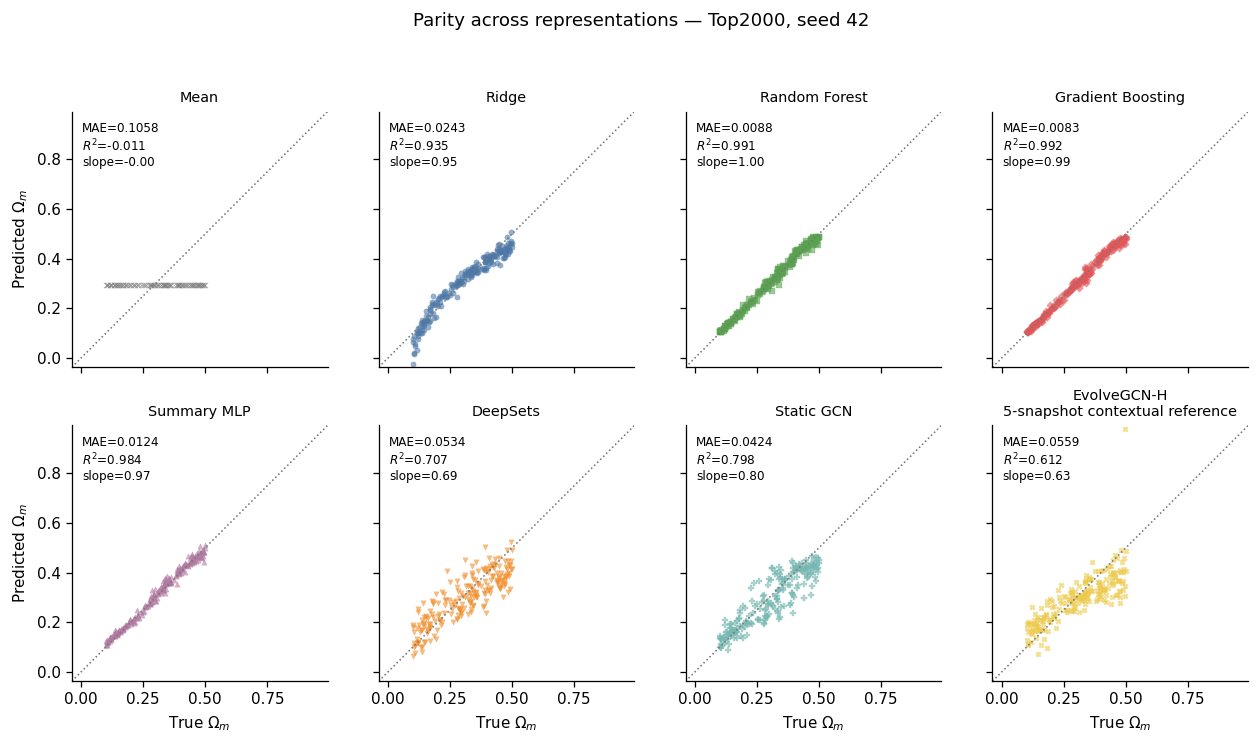

In [9]:
def get_test(model,top,seed):
    chosen_top=1000 if model=='Mean' else top
    return predictions[(predictions.Model==model)&(predictions['Top-N']==chosen_top)&(predictions.Seed==seed)&(predictions.Partition=='test')]

def parity_figure(top,seed,filename):
    frames=[get_test(m,top,seed) for m in MODELS]
    low=min(float(f[['true_omega_m','pred_omega_m']].min().min()) for f in frames)-.015
    high=max(float(f[['true_omega_m','pred_omega_m']].max().max()) for f in frames)+.015
    fig,axes=plt.subplots(2,4,figsize=(13.2,6.5),sharex=True,sharey=True)
    for ax,model,f in zip(axes.flat,MODELS,frames):
        truth=f.true_omega_m.to_numpy(float); pred=f.pred_omega_m.to_numpy(float)
        slope,intercept=np.polyfit(truth,pred,1); met=metrics_from_predictions(f)
        ax.scatter(truth,pred,s=11,alpha=.58,color=STYLES[model]['color'],marker=STYLES[model]['marker'],linewidths=.25)
        ax.plot([low,high],[low,high],color='#777777',ls=':',lw=1)
        title=model if model!='EvolveGCN-H' else 'EvolveGCN-H\n5-snapshot contextual reference'
        ax.set_title(title,fontsize=9)
        ax.text(.04,.96,f"MAE={met['mae']:.4f}\n$R^2$={met['r2']:.3f}\nslope={slope:.2f}",transform=ax.transAxes,va='top',fontsize=7.5)
        ax.set_xlim(low,high); ax.set_ylim(low,high); ax.set_aspect('equal',adjustable='box')
    for ax in axes[-1]: ax.set_xlabel(r'True $\Omega_m$')
    for ax in axes[:,0]: ax.set_ylabel(r'Predicted $\Omega_m$')
    fig.suptitle(f'Parity across representations — Top{top}, seed {seed}',y=1.01)
    savefig(fig,filename)

parity_figure(2000,42,'fig04d_parity_top2000_seed42.png')

**What this figure shows.** RF and GB track $y=x$ most tightly and cover most of the target range. Summary MLP shows mild range attenuation. DeepSets and Static GCN show stronger low-$\Omega_m$ overprediction and high-$\Omega_m$ underprediction, although Static is more accurate. EvolveGCN-H has strong, seed-dependent attenuation in the tested configuration.

**Scientific interpretation.** The raw-halo neural gap is associated with prediction compression and incomplete extraction of global distributional information, not absence of learnable cosmological signal. Spread alone is not accuracy: Static GCN can have a lower spread ratio than DeepSets while also achieving lower MAE.

# 11 — Regression Toward the Mean

For each test prediction file, fit $\widehat{\Omega}_m=\alpha+\beta\Omega_m$. The slope $\beta$ measures aligned target-range response; the spread ratio $s_{\hat y}/s_y$ measures marginal spread. Neither is sufficient alone, so both are reported with bias, residual slope, and MAE.

In [10]:
diag_rows=[]
for model in MODELS:
    tops=TOP_NS if model!='Mean' else [500,1000,1500,2000]
    for top in tops:
        for seed in SEEDS:
            f=get_test(model,top,seed); truth=f.true_omega_m.to_numpy(float); pred=f.pred_omega_m.to_numpy(float)
            slope,intercept=np.polyfit(truth,pred,1); rslope,_=np.polyfit(truth,pred-truth,1)
            diag_rows.append({'Model':model,'Top-N':top,'Seed':seed,'Prediction bias':float(np.mean(pred-truth)),'Target SD':float(np.std(truth,ddof=1)),'Prediction SD':float(np.std(pred,ddof=1)),'Spread ratio':float(np.std(pred,ddof=1)/np.std(truth,ddof=1)),'Prediction-vs-truth slope':float(slope),'Residual-vs-truth slope':float(rslope),'Test MAE':float(np.mean(np.abs(pred-truth)))})
diag_seed=pd.DataFrame(diag_rows)
agg_cols=['Prediction bias','Target SD','Prediction SD','Spread ratio','Prediction-vs-truth slope','Residual-vs-truth slope','Test MAE']
parts=[]
for (model,top),g in diag_seed.groupby(['Model','Top-N'],sort=False):
    row={'Model':model,'Top-N':top}
    for c in agg_cols: row[c+' mean']=g[c].mean(); row[c+' SD']=g[c].std(ddof=1)
    parts.append(row)
table06=pd.DataFrame(parts)
table06['Model']=pd.Categorical(table06.Model,MODELS,ordered=True); table06=table06.sort_values(['Model','Top-N']); table06['Model']=table06.Model.astype(str)
table06.to_csv(OUTPUT_DIR/'table06_prediction_compression.csv',index=False)
display(table06[['Model','Top-N','Prediction bias mean','Spread ratio mean','Prediction-vs-truth slope mean','Residual-vs-truth slope mean','Test MAE mean']].style.format({c:'{:.4f}' for c in ['Prediction bias mean','Spread ratio mean','Prediction-vs-truth slope mean','Residual-vs-truth slope mean','Test MAE mean']}))

,Model,Top-N,Prediction bias mean,Spread ratio mean,Prediction-vs-truth slope mean,Residual-vs-truth slope mean,Test MAE mean
0,Mean,500,-0.0049,0.0000,-0.0000,-1.0000,0.1036
1,Mean,1000,-0.0049,0.0000,-0.0000,-1.0000,0.1036
2,Mean,1500,-0.0049,0.0000,-0.0000,-1.0000,0.1036
3,Mean,2000,-0.0049,0.0000,-0.0000,-1.0000,0.1036
4,Ridge,500,-0.0025,0.9758,0.9426,-0.0574,0.0245
5,Ridge,1000,-0.0020,0.9668,0.9389,-0.0611,0.0225
6,Ridge,1500,-0.0021,0.9710,0.9392,-0.0608,0.0240
7,Ridge,2000,-0.0026,0.9689,0.9360,-0.0640,0.0249
8,Random Forest,500,-0.0004,0.9910,0.9825,-0.0175,0.0117
9,Random Forest,1000,-0.0002,0.9968,0.9903,-0.0097,0.0101


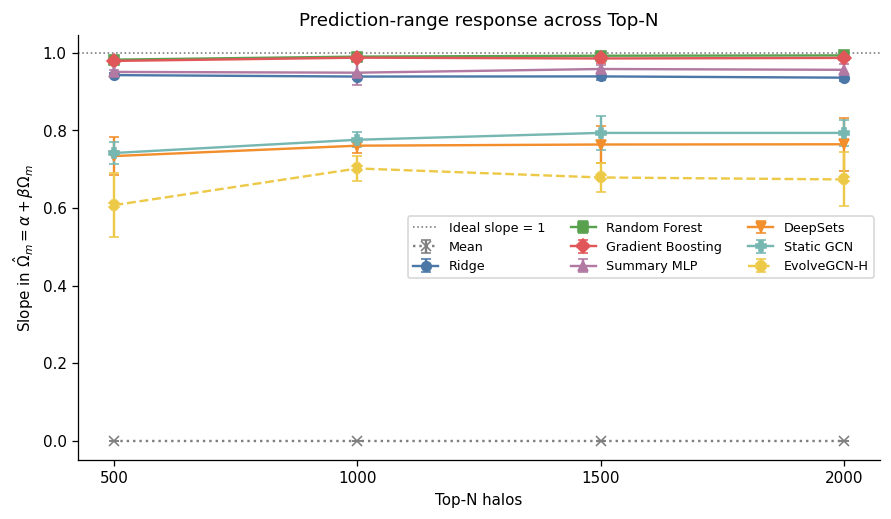

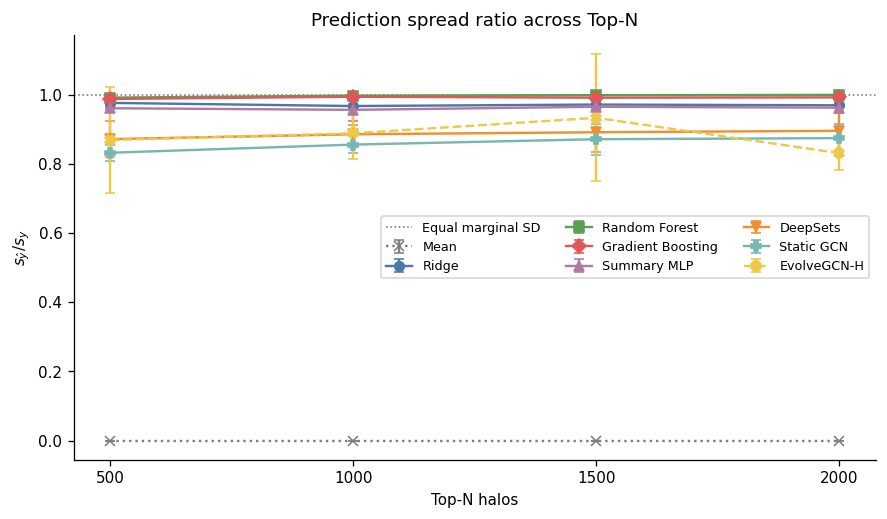

In [11]:
fig,ax=plt.subplots(figsize=(9,4.8))
for model in MODELS:
    g=diag_seed[diag_seed.Model==model].groupby('Top-N')['Prediction-vs-truth slope'].agg(['mean','std']); st=STYLES[model]
    ax.errorbar(g.index,g['mean'],yerr=g['std'],label=model,capsize=3,**st)
ax.axhline(1,color='#777777',ls=':',lw=1,label='Ideal slope = 1')
ax.set(title=r'Prediction-range response across Top-N',xlabel='Top-N halos',ylabel=r'Slope in $\hat{\Omega}_m=\alpha+\beta\Omega_m$',xticks=TOP_NS)
ax.legend(ncol=3,fontsize=8)
fig05=savefig(fig,'fig05_prediction_slope_vs_topn.png')

fig,ax=plt.subplots(figsize=(9,4.8))
for model in MODELS:
    g=diag_seed[diag_seed.Model==model].groupby('Top-N')['Spread ratio'].agg(['mean','std']); st=STYLES[model]
    ax.errorbar(g.index,g['mean'],yerr=g['std'],label=model,capsize=3,**st)
ax.axhline(1,color='#777777',ls=':',lw=1,label='Equal marginal SD')
ax.set(title='Prediction spread ratio across Top-N',xlabel='Top-N halos',ylabel=r'$s_{\hat y}/s_y$',xticks=TOP_NS)
ax.legend(ncol=3,fontsize=8)
fig06=savefig(fig,'fig06_prediction_spread_ratio_vs_topn.png')

# 12 — Residual Structure

Residual is defined as $\widehat{\Omega}_m-\Omega_m$. A negative fitted residual slope is the same attenuation seen from parity slopes below one.

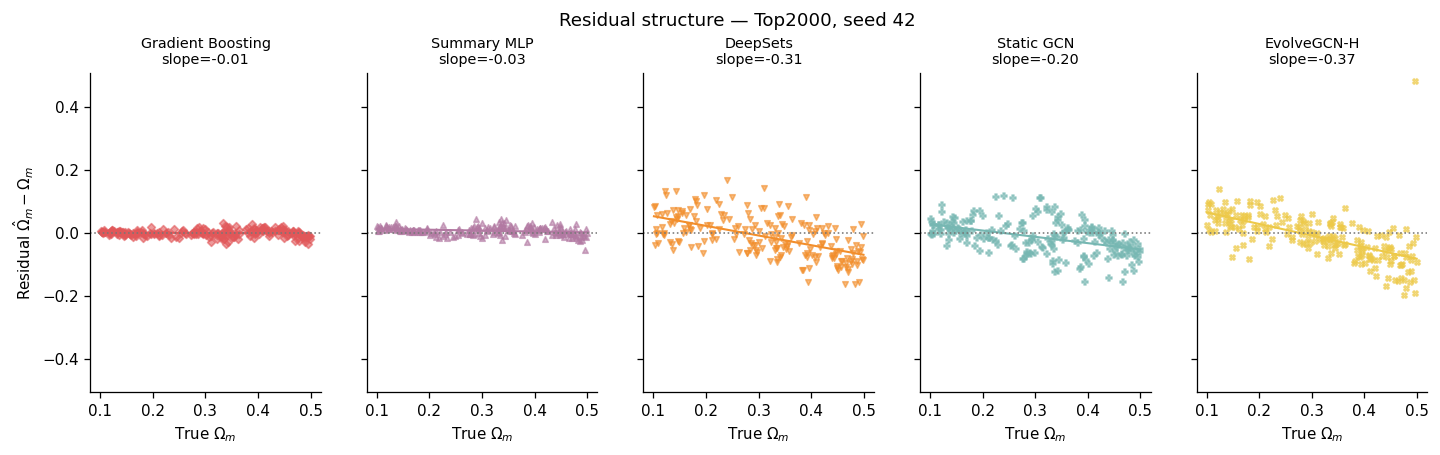

In [12]:
res_models=['Gradient Boosting','Summary MLP','DeepSets','Static GCN','EvolveGCN-H']
frames=[get_test(m,2000,42) for m in res_models]
ylim=max(max(abs(float((f.pred_omega_m-f.true_omega_m).min())) for f in frames), max(abs(float((f.pred_omega_m-f.true_omega_m).max())) for f in frames))
fig,axes=plt.subplots(1,5,figsize=(15,3.6),sharex=True,sharey=True)
for ax,model,f in zip(axes,res_models,frames):
    x=f.true_omega_m.to_numpy(float); y=f.pred_omega_m.to_numpy(float)-x; slope,intercept=np.polyfit(x,y,1)
    ax.scatter(x,y,s=12,alpha=.6,color=STYLES[model]['color'],marker=STYLES[model]['marker'])
    xx=np.array([x.min(),x.max()]); ax.plot(xx,intercept+slope*xx,color=STYLES[model]['color'],lw=1.3)
    ax.axhline(0,color='#777777',ls=':',lw=1); ax.set_title(f'{model}\nslope={slope:.2f}',fontsize=9); ax.set_xlabel(r'True $\Omega_m$')
    ax.set_ylim(-ylim*1.05,ylim*1.05)
axes[0].set_ylabel(r'Residual $\hat{\Omega}_m-\Omega_m$')
fig.suptitle('Residual structure — Top2000, seed 42',y=1.03)
fig07=savefig(fig,'fig07_residual_vs_truth_top2000_seed42.png')

**What this figure shows.** The negative residual trends expose regression toward the target mean: low targets tend toward positive residuals and high targets toward negative residuals. The effect is mildest for Gradient Boosting, larger for Summary MLP, and stronger for the raw-set and graph models.

# 13 — Generalization: Train / Validation / Test Behavior

Train, validation, and test errors are compared without equating a train–test gap by itself with overfitting. Validation/test agreement and absolute training error are considered jointly.

Partition,Model,Top-N,Test MAE,Train MAE,Validation MAE,Train-test MAE gap
12,Mean,Invariant,0.10363,0.09867,0.10222,+0.00496
20,Ridge,2000,0.02486,0.02517,0.02523,-0.00031
16,Random Forest,2000,0.00926,0.00386,0.00955,+0.00540
11,Gradient Boosting,2000,0.00866,0.00482,0.00849,+0.00384
28,Summary MLP,2000,0.01107,0.00830,0.01005,+0.00277
3,DeepSets,2000,0.04861,0.04560,0.04626,+0.00301
24,Static GCN,2000,0.03933,0.03212,0.03838,+0.00722
7,EvolveGCN-H,2000,0.05461,0.03849,0.05227,+0.01612


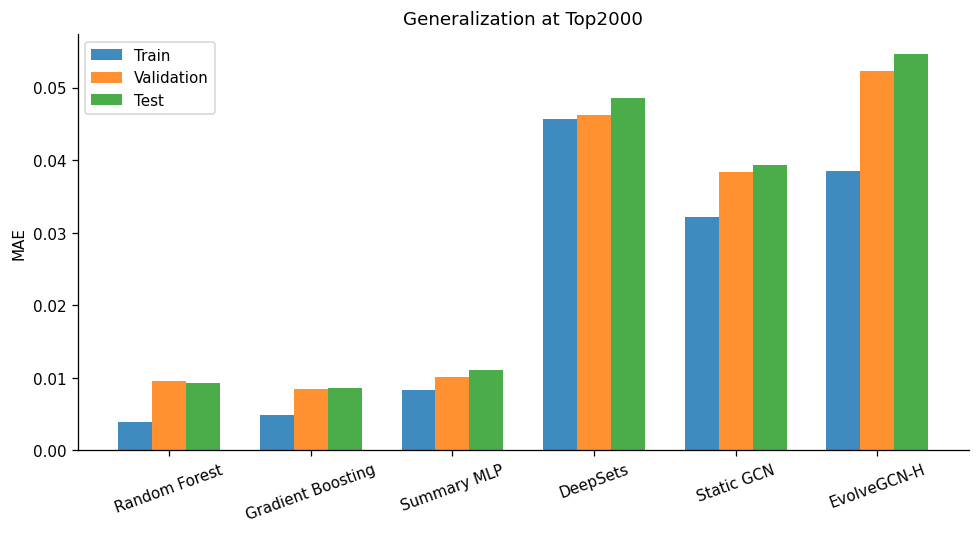

In [13]:
table07=(metrics.groupby(['Model','Top-N','Partition'],dropna=False).mae.mean().unstack('Partition').reset_index().rename(columns={'train':'Train MAE','val':'Validation MAE','test':'Test MAE'}))
table07['Train-test MAE gap']=table07['Test MAE']-table07['Train MAE']
table07['Model']=pd.Categorical(table07.Model,MODELS,ordered=True); table07=table07.sort_values(['Model','Top-N']); table07['Model']=table07.Model.astype(str)
table07.to_csv(OUTPUT_DIR/'table07_generalization.csv',index=False)
display(table07[table07['Top-N'].isna() | (table07['Top-N']==2000)].style.format({'Top-N':lambda x:'Invariant' if pd.isna(x) else str(int(x)),'Train MAE':'{:.5f}','Validation MAE':'{:.5f}','Test MAE':'{:.5f}','Train-test MAE gap':'{:+.5f}'}))

show_models=['Random Forest','Gradient Boosting','Summary MLP','DeepSets','Static GCN','EvolveGCN-H']
plot=table07[(table07['Top-N']==2000)&table07.Model.isin(show_models)].set_index('Model').loc[show_models]
x=np.arange(len(show_models)); width=.24
fig,ax=plt.subplots(figsize=(10,4.7))
for i,(col,label) in enumerate([('Train MAE','Train'),('Validation MAE','Validation'),('Test MAE','Test')]):
    ax.bar(x+(i-1)*width,plot[col],width,label=label,alpha=.86)
ax.set(title='Generalization at Top2000',ylabel='MAE',xticks=x,xticklabels=show_models)
ax.tick_params(axis='x',rotation=20); ax.legend()
fig08=savefig(fig,'fig08_generalization.png')

**Scientific interpretation.** Ridge exhibits clean generalization. RF and GB have lower training error but closely aligned validation and test errors, while remaining the strongest test models. Summary MLP generalizes well. DeepSets combines high training error with small gaps, evidence consistent with underfitting. Static GCN has a moderate gap; EvolveGCN-H has larger and more variable gaps. These are diagnostic patterns, not one-number diagnoses.

# 14 — Top-N Scaling Across Representations

Marginal gain is previous mean test MAE minus next mean test MAE: positive values improve and negative values degrade. Claims are limited to diminishing returns within the tested range.

In [14]:
gain_rows=[]
for model in MODELS[1:]:
    vals=table02[table02.Model==model].set_index('Top-N')['MAE mean']
    for a,b in zip(TOP_NS[:-1],TOP_NS[1:]):
        gain=vals[a]-vals[b]
        gain_rows.append({'Model':model,'Transition':f'{a} → {b}','Previous Top-N':a,'Next Top-N':b,'MAE improvement':gain,'Percentage change':100*gain/vals[a]})
table08=pd.DataFrame(gain_rows)
table08['Model']=pd.Categorical(table08.Model,MODELS,ordered=True); table08=table08.sort_values(['Model','Previous Top-N']); table08['Model']=table08.Model.astype(str)
table08.to_csv(OUTPUT_DIR/'table08_topn_marginal_gains.csv',index=False)
display(table08.style.format({'MAE improvement':'{:+.6f}','Percentage change':'{:+.2f}%'}))

,Model,Transition,Previous Top-N,Next Top-N,MAE improvement,Percentage change
0,Ridge,500 → 1000,500,1000,+0.002057,+8.39%
1,Ridge,1000 → 1500,1000,1500,-0.001499,-6.67%
2,Ridge,1500 → 2000,1500,2000,-0.000888,-3.70%
3,Random Forest,500 → 1000,500,1000,+0.001581,+13.54%
4,Random Forest,1000 → 1500,1000,1500,+0.000717,+7.11%
5,Random Forest,1500 → 2000,1500,2000,+0.000114,+1.21%
6,Gradient Boosting,500 → 1000,500,1000,+0.001468,+12.77%
7,Gradient Boosting,1000 → 1500,1000,1500,+0.000859,+8.56%
8,Gradient Boosting,1500 → 2000,1500,2000,+0.000509,+5.55%
9,Summary MLP,500 → 1000,500,1000,+0.001729,+12.25%


Ridge is best around Top1000 and then degrades; RF improves strongly with small high-N gains; GB improves monotonically; Summary MLP improves overall with diminishing high-N gains; DeepSets is best around Top1000 and then modestly degrades; Static GCN improves through Top1500 and worsens at Top2000; and EvolveGCN-H improves overall but remains seed-dependent. These finite-grid patterns do not establish asymptotic saturation or show that lower-mass halos contain no additional information.

# 15 — Scientific Synthesis

The dataset contains strong learnable $\Omega_m$ signal, exposed especially efficiently by engineered final-snapshot global halo statistics. Nonlinear tree models use those summaries particularly well, while Summary MLP confirms that a neural model can also learn the target strongly from the same representation. The tested DeepSets architecture is substantially worse than the strongest engineered-summary models across the tested Top-N values; this does not establish that raw halo catalogues contain less cosmological information because representation, inductive bias, capacity, and optimization differ. Static GCN consistently improves over DeepSets, showing that the tested graph-based model extracts predictive information more effectively than the tested unordered-set model, yet remains well behind the summary models. Prediction compression and difficulty preserving or extracting global halo-distribution information therefore remain plausible explanations for the graph-model gap. The tested five-snapshot EvolveGCN-H contextual temporal reference does not improve on Static GCN, but this comparison does not isolate temporal information.

# 16 — Limitations

- Only three random seeds are available; no formal significance claim is made.
- DeepSets and Static GCN are closely matched but not parameter-identical, so graph edges alone are not isolated.
- The 20-feature summary representation is handcrafted; Cartesian position summaries are coordinate-origin sensitive, and `halo_count` is constant within each Top-N experiment.
- EvolveGCN-H has a different information budget and architecture from Static GCN.
- Only four finite Top-N values are tested. The results neither show that lower-mass halos lack additional information nor establish permanent saturation.
- No separate hyperparameter search was performed for every model family in this controlled comparison.
- Conclusions apply to the tested architectures and protocols, not universally to all graph, set, summary, or temporal models.

# 17 — Answers to the Research Questions

The evidence/status table distinguishes direct answers from comparisons confounded by model and information-budget differences.

In [15]:
best=table02[table02.Model!='Mean'].sort_values('MAE mean').iloc[0]
best_neural=table02[table02.Model=='Summary MLP'].sort_values('MAE mean').iloc[0]
best_static=table02[table02.Model=='Static GCN'].sort_values('MAE mean').iloc[0]
best_ds=table02[table02.Model=='DeepSets'].sort_values('MAE mean').iloc[0]
table09=pd.DataFrame([
['Q1. Do engineered summaries contain strong signal?','ANSWERED',f"Best Ridge MAE {ridge_best['MAE mean']:.5f} vs Mean {mean_mae:.5f}; RF/GB improve further.",'Summaries are not proven sufficient.'],
['Q2. Do nonlinear models improve upon linear regression?','ANSWERED','RF and GB beat Ridge at every Top-N.','Evidence concerns tested model classes, not a causal physical mapping.'],
['Q3. Can a neural network exploit the same summaries?','ANSWERED',f"Summary MLP best mean MAE {best_neural['MAE mean']:.5f}; trees win every Top-N.",'One MLP configuration; no family-specific search.'],
['Q4. Does raw individual-halo set modeling outperform engineered summaries?','PARTIALLY ANSWERED','The tested DeepSets architecture is substantially worse than the strongest engineered-summary models across the tested Top-N values.','This does not establish that raw halo catalogues contain less cosmological information because representation, inductive bias, capacity, and optimization differ.'],
['Q5. Does explicit graph message passing outperform an unordered set?','PARTIALLY ANSWERED','Static GCN wins 12/12 matched DeepSets cells.','Parameter count and node transformations differ; edges alone are not isolated.'],
['Q6. Does tested EvolveGCN-H outperform Static GCN?','PARTIALLY ANSWERED',f'Static GCN wins {static_wins}/12 tested cells against the five-snapshot contextual temporal reference.','Static receives one final snapshot, EvolveGCN-H receives five, and the architectures differ; temporal value is not isolated.'],
['Q7. How does Top-N affect each representation?','ANSWERED','Model-specific gains and degradations are tabulated over Top500–2000.','Finite grid only.'],
['Q8. Which representations regress most toward the mean?','ANSWERED','Parity, fitted slope, spread, and residual trends show least compression for RF/GB and stronger attenuation for raw-set/graph models.','Descriptive within the tested matrix; compression varies by seed and slope/spread are diagnostics, not accuracy metrics.'],
],columns=['Question','Status','Evidence','Limitation'])
table09.to_csv(OUTPUT_DIR/'table09_scientific_questions.csv',index=False)
display(table09)

,Question,Status,Evidence,Limitation
0,Q1. Do engineered summaries contain strong sig...,ANSWERED,Best Ridge MAE 0.02247 vs Mean 0.10363; RF/GB ...,Summaries are not proven sufficient.
1,Q2. Do nonlinear models improve upon linear re...,ANSWERED,RF and GB beat Ridge at every Top-N.,"Evidence concerns tested model classes, not a ..."
2,Q3. Can a neural network exploit the same summ...,ANSWERED,Summary MLP best mean MAE 0.01107; trees win e...,One MLP configuration; no family-specific search.
3,Q4. Does raw individual-halo set modeling outp...,PARTIALLY ANSWERED,The tested DeepSets architecture is substantia...,This does not establish that raw halo catalogu...
4,Q5. Does explicit graph message passing outper...,PARTIALLY ANSWERED,Static GCN wins 12/12 matched DeepSets cells.,Parameter count and node transformations diffe...
5,Q6. Does tested EvolveGCN-H outperform Static ...,PARTIALLY ANSWERED,Static GCN wins 12/12 tested cells against the...,"Static receives one final snapshot, EvolveGCN-..."
6,Q7. How does Top-N affect each representation?,ANSWERED,Model-specific gains and degradations are tabu...,Finite grid only.
7,Q8. Which representations regress most toward ...,ANSWERED,"Parity, fitted slope, spread, and residual tre...",Descriptive within the tested matrix; compress...


# 18 — Thesis Takeaways

The next cell derives the headline statements directly from the computed tables rather than encoding audit values.

In [16]:
best_preserve=(table06[table06.Model!='Mean'].groupby('Model')['Prediction-vs-truth slope mean'].apply(lambda s: (s-1).abs().mean()).sort_values())
summary_best=best
static_gap=(best_static['MAE mean']-summary_best['MAE mean'])/summary_best['MAE mean']*100
display(Markdown(f"""
- **Strongest tested model/Top-N:** {summary_best.Model}, Top{int(summary_best['Top-N'])}, test MAE {summary_best['MAE mean']:.6f} ± {summary_best['MAE SD']:.6f}.
- **Strongest neural summary result:** Summary MLP, Top{int(best_neural['Top-N'])}, MAE {best_neural['MAE mean']:.6f} ± {best_neural['MAE SD']:.6f}.
- **Matched raw-halo comparison:** Static GCN wins {int((table05.Winner=='Static GCN').sum())}/12 against DeepSets.
- **Temporal-context comparison:** Static GCN wins {static_wins}/12 against EvolveGCN-H; this does not isolate temporal information.
- **Best Top-N:** Static GCN Top{int(best_static['Top-N'])}; DeepSets Top{int(best_ds['Top-N'])}.
- **Best-summary vs Static gap:** the best Static GCN mean MAE is {static_gap:.1f}% higher than the strongest summary-model cell.
- **Target-range preservation:** {best_preserve.index[0]} has the closest average slope to one; {best_preserve.index[-1]} has the strongest average attenuation by this diagnostic.
"""))


- **Strongest tested model/Top-N:** Gradient Boosting, Top2000, test MAE 0.008664 ± 0.000439.
- **Strongest neural summary result:** Summary MLP, Top2000, MAE 0.011074 ± 0.001142.
- **Matched raw-halo comparison:** Static GCN wins 12/12 against DeepSets.
- **Temporal-context comparison:** Static GCN wins 12/12 against EvolveGCN-H; this does not isolate temporal information.
- **Best Top-N:** Static GCN Top1500; DeepSets Top1000.
- **Best-summary vs Static gap:** the best Static GCN mean MAE is 337.3% higher than the strongest summary-model cell.
- **Target-range preservation:** Random Forest has the closest average slope to one; EvolveGCN-H has the strongest average attenuation by this diagnostic.


# 19 — Supplementary Parity Figures

The complete parity coverage uses the same eight-panel order—Mean, Ridge, Random Forest, Gradient Boosting, Summary MLP, DeepSets, Static GCN, EvolveGCN-H. Seed42 is shown at all four Top-N values; Top2000 is repeated for seeds 123 and 2025 to assess reproducibility. The already displayed Top2000/seed42 figure is not regenerated.

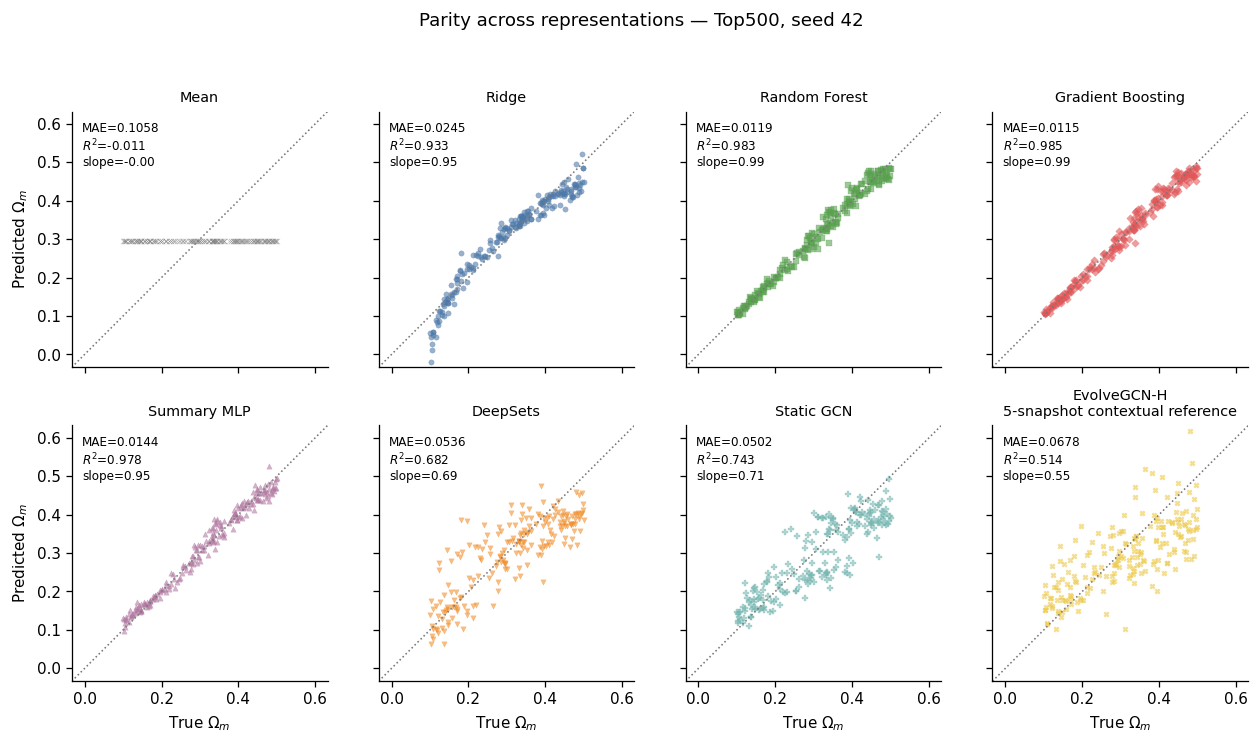

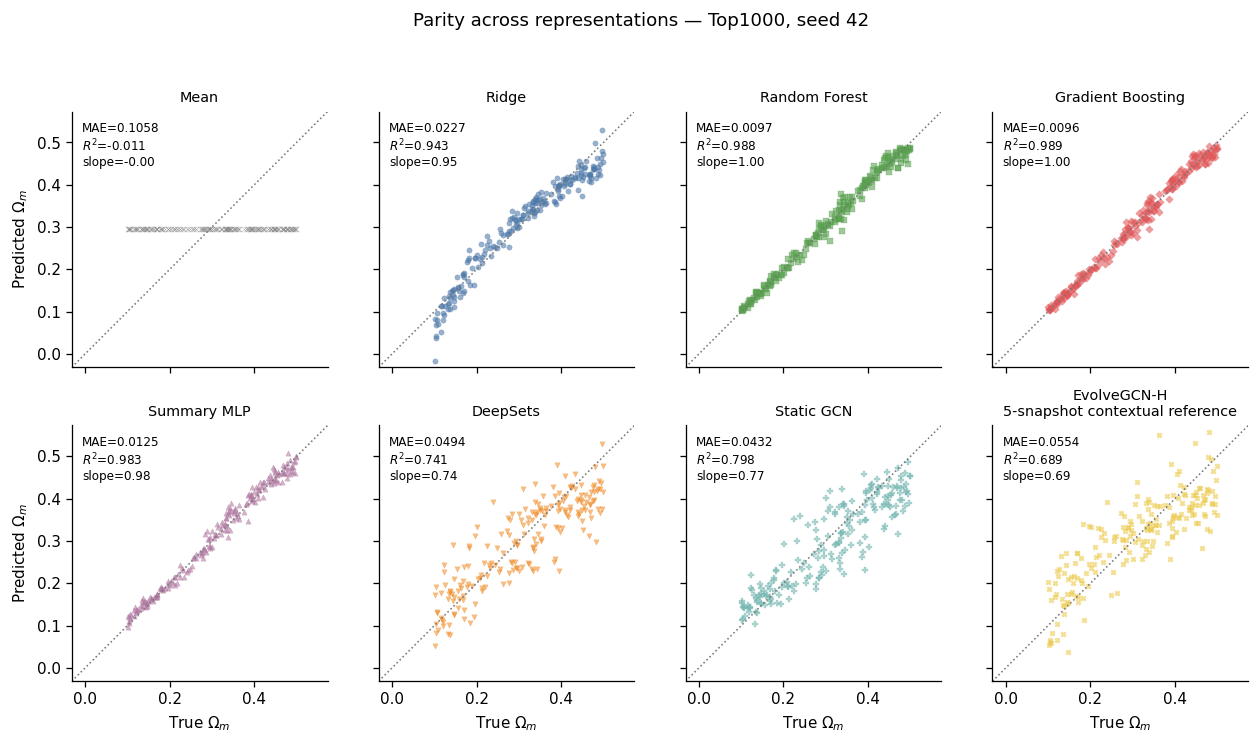

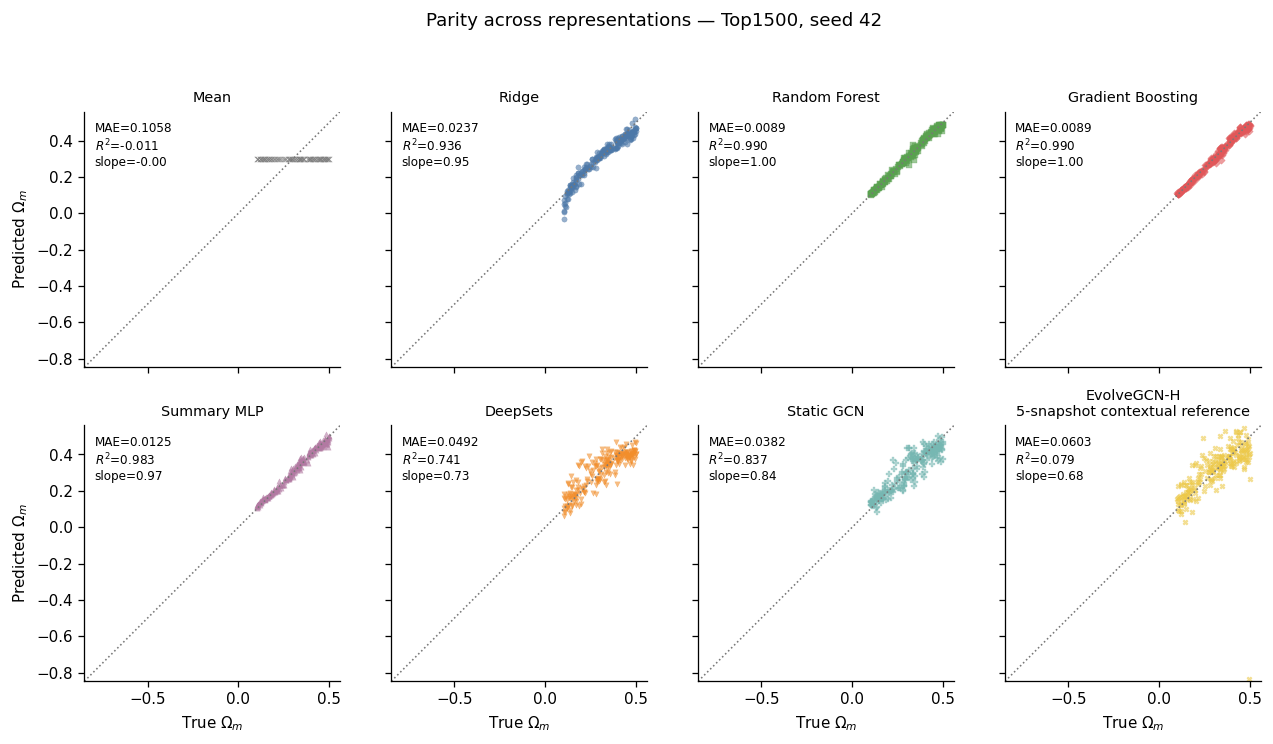

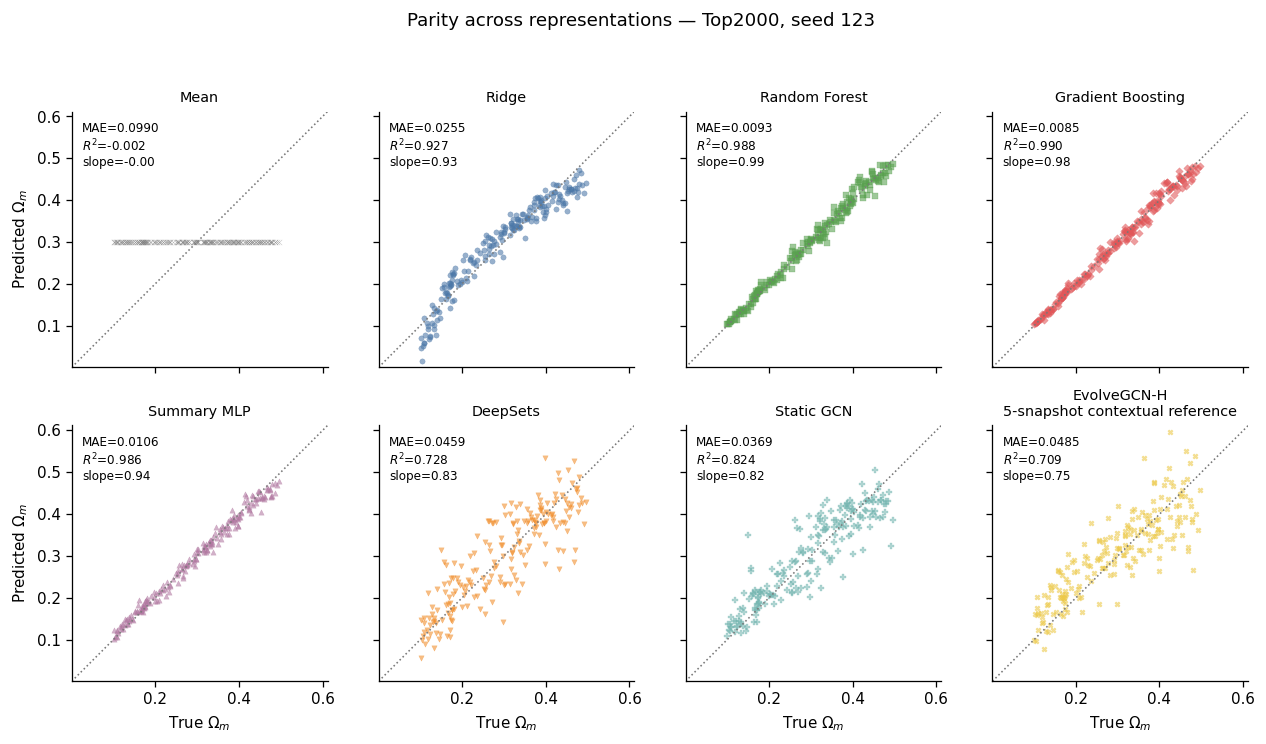

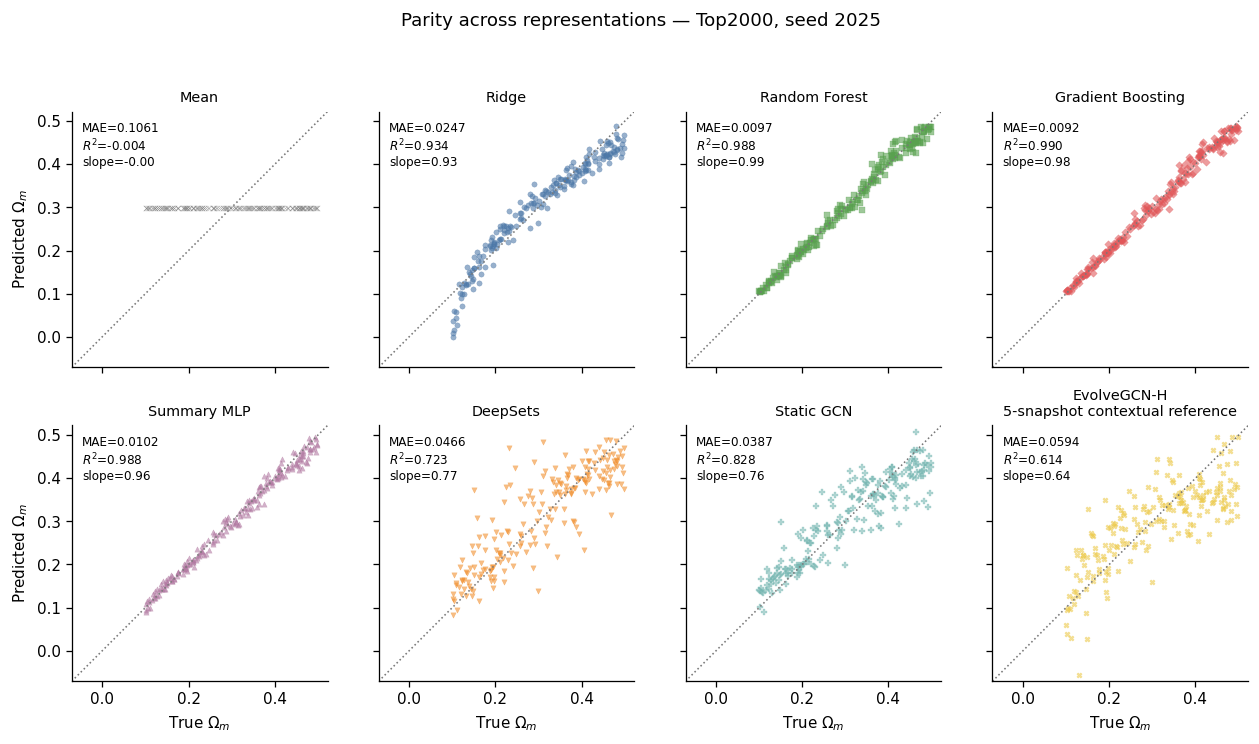

In [17]:
parity_figure(500,42,'fig04a_parity_top500_seed42.png')
parity_figure(1000,42,'fig04b_parity_top1000_seed42.png')
parity_figure(1500,42,'fig04c_parity_top1500_seed42.png')
parity_figure(2000,123,'fig04e_parity_top2000_seed123.png')
parity_figure(2000,2025,'fig04f_parity_top2000_seed2025.png')

# 20 — Reproducibility / Provenance Appendix

The final cell exports the complete per-seed performance and representation hierarchy tables, then validates every required CSV and PNG. Cross-seed standard deviations use sample SD (`ddof=1`). Metrics use MAE $=n^{-1}\sum|\hat y-y|$, MSE $=n^{-1}\sum(\hat y-y)^2$, RMSE $=\sqrt{\mathrm{MSE}}$, and $R^2=1-\sum(\hat y-y)^2/\sum(y-\bar y)^2$.

**Separate next phase.** The remaining controlled question is how EvolveGCN-H performance changes as the number of temporal snapshots is varied while the remaining experiment settings are held fixed. That future snapshot-count ablation will compare 2, 3, 4, and 5 snapshots, with the final-snapshot/static reference where scientifically appropriate; it is not implemented or answered in this notebook.

In [18]:
table03=test_seed[['Model','Top-N','Seed','mae','rmse','r2','Best epoch']].rename(columns={'mae':'Test MAE','rmse':'Test RMSE','r2':'Test R2'}).copy()
table03['Model']=pd.Categorical(table03.Model,MODELS,ordered=True); table03=table03.sort_values(['Model','Top-N','Seed']); table03['Model']=table03.Model.astype(str)
table03.to_csv(OUTPUT_DIR/'table03_per_seed_performance.csv',index=False)

table04=pd.DataFrame([
['Mean','Target-only constant','Training targets','No input dependence','Establishes non-learning reference','No halo information'],
['Ridge / RF / GB','Engineered summaries','20 final-snapshot global summaries','Linear or tree ensemble','Tests summary signal and model class','Handcrafted, coordinate-sensitive components'],
['Summary MLP','Neural summaries','Same 20 final-snapshot summaries','Dense nonlinear network','Separates neural model class from raw representation','Still handcrafted input'],
['DeepSets','Raw set','Seven features per final-snapshot halo','Permutation invariance + masked mean','Tests direct unordered-halo learning','No explicit spatial edges'],
['Static GCN','Static graph','Same seven raw features + periodic kNN edges','Graph message passing + mean pooling','Closest graph-vs-set comparison','Not parameter-identical to DeepSets'],
['EvolveGCN-H','Temporal graph','Five graph snapshots','Evolving graph convolution + graph/temporal mean','Contextual temporal reference','Different information budget and architecture'],
],columns=['Model','Representation','Information available','Inductive bias','What comparison it enables','Main limitation'])
table04.to_csv(OUTPUT_DIR/'table04_representation_hierarchy.csv',index=False)

expected_csv = {
'table01_information_budget.csv':['Model','Representation','Input level','Snapshots','Engineered summaries?','Raw halos?','Graph edges?','Temporal?','Pooling','Approx. trainable parameters','Primary role in study'],
'table02_main_performance.csv':['Model','Top-N','MAE mean','MAE SD','RMSE mean','RMSE SD','R2 mean','R2 SD'],
'table03_per_seed_performance.csv':['Model','Top-N','Seed','Test MAE','Test RMSE','Test R2','Best epoch'],
'table04_representation_hierarchy.csv':['Model','Representation','Information available','Inductive bias','What comparison it enables','Main limitation'],
'table05_deepsets_vs_static.csv':['Top-N','Seed','DeepSets MAE','Static GCN MAE','DeepSets - Static MAE','Relative difference %','Winner'],
'table06_prediction_compression.csv':list(table06.columns),
'table07_generalization.csv':list(table07.columns),
'table08_topn_marginal_gains.csv':['Model','Transition','Previous Top-N','Next Top-N','MAE improvement','Percentage change'],
'table09_scientific_questions.csv':['Question','Status','Evidence','Limitation'],
'table10_run_provenance.csv':list(table10.columns),
}
expected_png=['fig01_test_mae_vs_topn.png','fig02_engineered_summary_models.png','fig03_deepsets_vs_static_paired.png','fig04a_parity_top500_seed42.png','fig04b_parity_top1000_seed42.png','fig04c_parity_top1500_seed42.png','fig04d_parity_top2000_seed42.png','fig04e_parity_top2000_seed123.png','fig04f_parity_top2000_seed2025.png','fig05_prediction_slope_vs_topn.png','fig06_prediction_spread_ratio_vs_topn.png','fig07_residual_vs_truth_top2000_seed42.png','fig08_generalization.png']
for name,cols in expected_csv.items():
    path=OUTPUT_DIR/name; assert path.is_file() and path.stat().st_size>0
    frame=pd.read_csv(path); assert len(frame)>0 and list(frame.columns)==cols
expected_rows={'table01_information_budget.csv':8,'table02_main_performance.csv':29,'table03_per_seed_performance.csv':87,'table04_representation_hierarchy.csv':6,'table05_deepsets_vs_static.csv':12,'table06_prediction_compression.csv':32,'table07_generalization.csv':29,'table08_topn_marginal_gains.csv':21,'table09_scientific_questions.csv':8,'table10_run_provenance.csv':87}
unique_keys={'table01_information_budget.csv':['Model'],'table02_main_performance.csv':['Model','Top-N'],'table03_per_seed_performance.csv':['Model','Top-N','Seed'],'table04_representation_hierarchy.csv':['Model'],'table05_deepsets_vs_static.csv':['Top-N','Seed'],'table06_prediction_compression.csv':['Model','Top-N'],'table07_generalization.csv':['Model','Top-N'],'table08_topn_marginal_gains.csv':['Model','Previous Top-N','Next Top-N'],'table09_scientific_questions.csv':['Question'],'table10_run_provenance.csv':['Experiment']}
for name in expected_csv:
    frame=pd.read_csv(OUTPUT_DIR/name)
    assert len(frame)==expected_rows[name], f'Unexpected row count: {name}'
    assert not frame.duplicated(unique_keys[name]).any(), f'Duplicate key: {name}'
    numeric=frame.select_dtypes(include=[np.number])
    allowed_nan={'table02_main_performance.csv':['Top-N'],'table03_per_seed_performance.csv':['Top-N','Best epoch'],'table07_generalization.csv':['Top-N'],'table10_run_provenance.csv':['Top-N','Best epoch']}.get(name,[])
    for column in numeric.columns:
        values=numeric[column].dropna() if column in allowed_nan else numeric[column]
        assert np.isfinite(values.to_numpy()).all(), f'Non-finite numeric value: {name} {column}'
for name in expected_png:
    path=OUTPUT_DIR/name; assert path.is_file() and path.stat().st_size>20_000
    with path.open('rb') as f:
        assert f.read(8)==b'\x89PNG\r\n\x1a\n'
        length=int.from_bytes(f.read(4),'big'); assert f.read(4)==b'IHDR'; data=f.read(length)
        width,height=int.from_bytes(data[:4],'big'),int.from_bytes(data[4:8],'big')
        assert width>=1000 and height>=650, f'Unexpected dimensions for {name}: {width}x{height}'

branch=subprocess.check_output(['git','branch','--show-current'],cwd=REPO,text=True).strip()
head=subprocess.check_output(['git','rev-parse','HEAD'],cwd=REPO,text=True).strip()
display(table04)
display(Markdown(f"""**Provenance.** Branch `{branch}`; HEAD `{head}`; created `{CREATED_AT}`. Four datasets and twelve split manifests are listed in `table10_run_provenance.csv` with their verified SHA-256 bindings. Expected/validated runs: 87/87. Prediction files checked: {prediction_files_checked}. Metric comparisons: {metric_comparisons} at `rtol={RTOL}`, `atol={ATOL}`. Sample SD uses `ddof=1`. Outputs: {len(expected_csv)} CSV tables and {len(expected_png)} PNG figures. This notebook performs no training and no checkpoint inference."""))
print(f'OUTPUT VALIDATION: PASS — {len(expected_csv)} CSVs and {len(expected_png)} PNGs are present, non-empty, structurally valid, and deterministically named.')

,Model,Representation,Information available,Inductive bias,What comparison it enables,Main limitation
0,Mean,Target-only constant,Training targets,No input dependence,Establishes non-learning reference,No halo information
1,Ridge / RF / GB,Engineered summaries,20 final-snapshot global summaries,Linear or tree ensemble,Tests summary signal and model class,"Handcrafted, coordinate-sensitive components"
2,Summary MLP,Neural summaries,Same 20 final-snapshot summaries,Dense nonlinear network,Separates neural model class from raw represen...,Still handcrafted input
3,DeepSets,Raw set,Seven features per final-snapshot halo,Permutation invariance + masked mean,Tests direct unordered-halo learning,No explicit spatial edges
4,Static GCN,Static graph,Same seven raw features + periodic kNN edges,Graph message passing + mean pooling,Closest graph-vs-set comparison,Not parameter-identical to DeepSets
5,EvolveGCN-H,Temporal graph,Five graph snapshots,Evolving graph convolution + graph/temporal mean,Contextual temporal reference,Different information budget and architecture


**Provenance.** Branch `thesis-sparse-integrity-hardening`; HEAD `6be328c6223d6cb362a8ad431c859ac92688302d`; created `2026-08-24T20:51:59.849732+00:00`. Four datasets and twelve split manifests are listed in `table10_run_provenance.csv` with their verified SHA-256 bindings. Expected/validated runs: 87/87. Prediction files checked: 261. Metric comparisons: 1044 at `rtol=1e-09`, `atol=1e-12`. Sample SD uses `ddof=1`. Outputs: 10 CSV tables and 13 PNG figures. This notebook performs no training and no checkpoint inference.

OUTPUT VALIDATION: PASS — 10 CSVs and 13 PNGs are present, non-empty, structurally valid, and deterministically named.
